In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

### Boyas CTD6(UPCT) y SmartLagoon(UCAM)

In [49]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = ["CTD6"]
# Diccionario para guardar dataframes
dataframes_boya_upct = {}

# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
    
    # Leer cada archivo CSV y guardar el DataFrame en el diccionario con el mismo nombre que el archivo (sin la extensión)
    for archivo in archivos_csv:
        if archivo == "Transparency.csv":
            continue
        
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        # CARGAMOS SOLO CLOROFILA
        if nombre_variable == "Clorofila":
            dataframes_boya_upct[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)
        
for key, df in dataframes_boya_upct.items():
    df['Date'] = pd.to_datetime(df['Date'])
    dataframes_boya_upct[key] = df.set_index("Date") 

In [50]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaSMLG/"

# Diccionario para guardar dataframes
dataframes_boya_ucam = {}

ruta_carpeta = os.path.join(path)
# Verificar que sea una carpeta
if os.path.isdir(ruta_carpeta):
    # Buscar archivos que terminen en "-Pluviometro.parquet" en la carpeta
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith('Clorofila.parquet'):
            ruta_archivo = os.path.join(ruta_carpeta, archivo)
            df = pd.read_parquet(ruta_archivo)
            # Crear el nombre del dataframe usando el nombre de la carpeta
            nombre_df = f"Clorofila"
            # Almacenar el dataframe en el diccionario
            dataframes_boya_ucam[nombre_df] = df
        
for key, df in dataframes_boya_ucam.items():
    df['Date'] = pd.to_datetime(df['Date'])
    dataframes_boya_ucam[key] = df.set_index("Date") 

for key, df in dataframes_boya_ucam.items():
    df = df.resample('D').mean()
    #df = df.reset_index()
    dataframes_boya_ucam[key] = df


In [51]:
dataframes_boya_ucam["Clorofila"]

,3m
Date,
2022-10-14,3.041935
2022-10-15,1.958467
2022-10-16,1.724295
2022-10-17,1.693273
2022-10-18,1.639755
...,...
2024-05-09,29.602727
2024-05-10,32.730446
2024-05-11,27.811952


In [57]:
dataframes_boya_upct["CTD6_Clorofila"]["3.0"]

Date
2017-05-19    1.207364
2017-05-24    0.716199
2017-06-02    1.407943
2017-06-06    0.888658
2017-06-13    0.909915
                ...   
2024-06-18    0.295461
2024-06-25    0.464895
2024-07-03    0.414553
2024-07-09    0.563618
2024-07-18    0.366116
Name: 3.0, Length: 373, dtype: float64

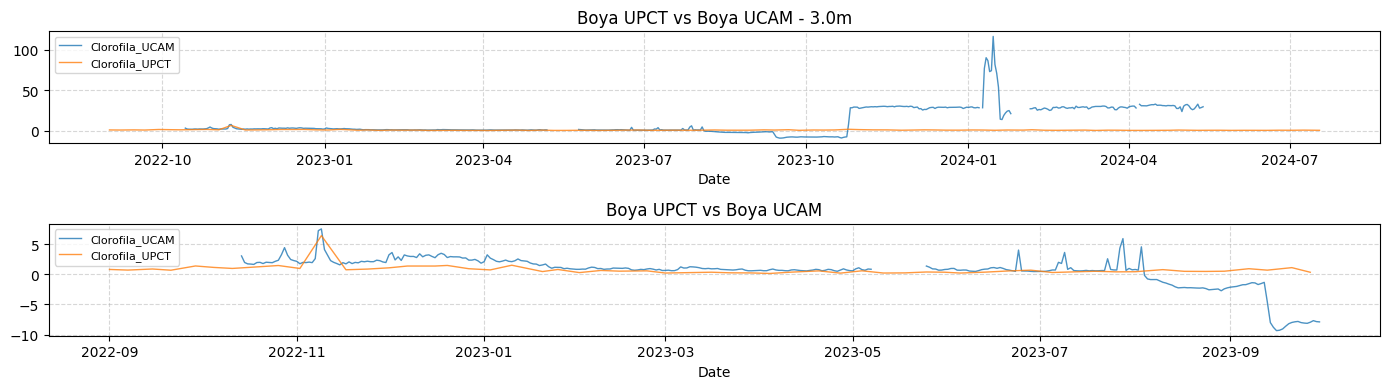

In [71]:
fig, axes = plt.subplots(figsize=(14, 4), nrows=2, ncols=1, sharex=False)

for i in range(2):
    ax = axes[i]
    if i == 0:
        start_date = '2022-08-30'
        clorofila_upct = dataframes_boya_upct["CTD6_Clorofila"][dataframes_boya_upct["CTD6_Clorofila"].index >= start_date]
        clorofila_ucam = dataframes_boya_ucam["Clorofila"][dataframes_boya_ucam["Clorofila"].index >= start_date]
        ax.plot(clorofila_ucam.index, clorofila_ucam["3m"], linewidth=1, alpha = 0.8, label = "Clorofila_UCAM")
        ax.plot(clorofila_upct.index, clorofila_upct["3.0"], linewidth=1, alpha = 0.8, label = "Clorofila_UPCT")
        ax.set_title("Boya UPCT vs Boya UCAM - 3.0m")
        ax.set_xlabel('Date')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, linestyle = '--', alpha = 0.5)
    if i == 1:
        start_date = '2022-08-30'
        end_date = '2023-09-30'
        clorofila_upct = dataframes_boya_upct["CTD6_Clorofila"][(dataframes_boya_upct["CTD6_Clorofila"].index >= start_date) & (dataframes_boya_upct["CTD6_Clorofila"].index <= end_date)]
        clorofila_ucam = dataframes_boya_ucam["Clorofila"][(dataframes_boya_ucam["Clorofila"].index >= start_date) & (dataframes_boya_ucam["Clorofila"].index <= end_date)]
        ax.plot(clorofila_ucam.index, clorofila_ucam["3m"], linewidth=1, alpha = 0.8, label = "Clorofila_UCAM")
        ax.plot(clorofila_upct.index, clorofila_upct["3.0"], linewidth=1, alpha = 0.8, label = "Clorofila_UPCT")
        ax.set_title("Boya UPCT vs Boya UCAM")
        ax.set_xlabel('Date')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, linestyle = '--', alpha = 0.5)

fig.tight_layout()

### Satélite

In [ ]:
path = "Copernicus"
filename = "buoy_satellite_index0.csv"
df_index0 = pd.read_csv(os.path.join(path, filename))
df_index0['Date'] = pd.to_datetime(df_index0['Date'])

filename = "buoy_satellite_index1.csv"
df_index1 = pd.read_csv(os.path.join(path, filename))
df_index1['Date'] = pd.to_datetime(df_index1['Date'])

filename = "buoy_satellite_index8.csv"
df_index8 = pd.read_csv(os.path.join(path, filename))
df_index8['Date'] = pd.to_datetime(df_index8['Date'])

# Porque los datos de lasboyas vienen sin guion
df_index0['Buoy'] = df_index0['Buoy'].str.replace('CTD-', 'CTD', regex=False)
df_index1['Buoy'] = df_index1['Buoy'].str.replace('CTD-', 'CTD', regex=False)
df_index8['Buoy'] = df_index8['Buoy'].str.replace('CTD-', 'CTD', regex=False)

# 1 dataframe por boya
dataframes_buoys_index0 = {buoy: group.reset_index(drop=True) for buoy, group in df_index0.groupby('Buoy')}
dataframes_buoys_index1 = {buoy: group.reset_index(drop=True) for buoy, group in df_index1.groupby('Buoy')}
dataframes_buoys_index8 = {buoy: group.reset_index(drop=True) for buoy, group in df_index8.groupby('Buoy')}